<a href="https://colab.research.google.com/github/Rishi5105-kashyap/Codtech-tasks/blob/main/codtech_task_1_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Codtech task 1 submission.

In [37]:
import requests
import zipfile
import os

url = 'http://files.grouplens.org/datasets/movielens/ml-100k.zip'
dataset_path = './ml-100k.zip'
extracted_path = './ml-100k'

if not os.path.exists(extracted_path):
    print(f"Downloading {url}...")
    response = requests.get(url)
    with open(dataset_path, 'wb') as f:
        f.write(response.content)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall('./')
    print("Extraction complete.")
else:
    print(f"Dataset already extracted at {extracted_path}.")

Dataset already extracted at ./ml-100k.


In [38]:
ratings_df = pd.read_csv(
    os.path.join(extracted_path, 'u.data'),
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

movies_df = pd.read_csv(
    os.path.join(extracted_path, 'u.item'),
    sep='|',
    encoding='latin-1',
    names=[
        'movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
        'unknown', 'Action', 'Adventure', 'Animation', 'Children\'s', 'Comedy',
        'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
        'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
    ]
)

merged_df = pd.merge(ratings_df, movies_df, left_on='item_id', right_on='movie_id')

print("Ratings DataFrame head:")
display(ratings_df.head())
print("\nMovies DataFrame head:")
display(movies_df.head())
print("\nMerged DataFrame head:")
display(merged_df.head())

Ratings DataFrame head:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



Movies DataFrame head:


,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



Merged DataFrame head:


,user_id,item_id,rating,timestamp,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,242,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,302,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,377,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,51,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,346,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
merged_df['is_high_rating'] = (merged_df['rating'] >= 4).astype(int)

genre_cols = [
    'unknown', 'Action', 'Adventure', 'Animation', 'Children\'s', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

X_movie_lens = merged_df[genre_cols].values
y_movie_lens = merged_df['is_high_rating'].values

feature_names_movie_lens = genre_cols
target_names_movie_lens = ['Low Rating (<4)', 'High Rating (>=4)']

print("\nSelected Features (X) shape:", X_movie_lens.shape)
print("Target (y) shape:", y_movie_lens.shape)
print("Feature Names:", feature_names_movie_lens)
print("Target Names:", target_names_movie_lens)


Selected Features (X) shape: (100000, 19)
Target (y) shape: (100000,)
Feature Names: ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Target Names: ['Low Rating (<4)', 'High Rating (>=4)']


In [28]:
# ============================================================
# STEP 1: LOAD DATASET - Assigning MovieLens variables
# ============================================================

X = X_movie_lens
y = y_movie_lens
feature_names = feature_names_movie_lens
target_names = target_names_movie_lens

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("\n===== FIRST 5 ROWS OF MOVIELENS DATASET ====")
print(df.head())

print("\n===== FEATURE NAMES ====")
print(feature_names)

print("\n===== TARGET NAMES ====")
print(target_names)


===== FIRST 5 ROWS OF MOVIELENS DATASET ====
   unknown  Action  Adventure  Animation  Children's  Comedy  Crime  \
0        0       0          0          0           0       1      0   
1        0       0          0          0           0       0      1   
2        0       0          0          0           1       1      0   
3        0       0          0          0           0       0      0   
4        0       0          0          0           0       0      1   

   Documentary  Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  Romance  \
0            0      0        0          0       0        0        0        0   
1            0      0        0          1       0        0        1        0   
2            0      0        0          0       0        0        0        0   
3            0      1        0          0       0        0        0        1   
4            0      1        0          0       0        0        0        0   

   Sci-Fi  Thriller  War  Western  target  
0 

In [29]:
# ============================================================
# STEP 2: SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\n===== DATASET SPLIT ====")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)


===== DATASET SPLIT ====
Training Data Shape: (70000, 19)
Testing Data Shape : (30000, 19)


In [30]:
# ============================================================
# STEP 3: BUILD DECISION TREE MODEL
# ============================================================

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("\n===== MODEL TRAINED SUCCESSFULLY ====")


===== MODEL TRAINED SUCCESSFULLY ====


In [31]:
# ============================================================
# STEP 4: MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\n===== PREDICTIONS (first 10) ====")
print(y_pred[:10])


===== PREDICTIONS (first 10) ====
[0 0 0 1 1 1 1 1 1 0]



===== ACCURACY ====
Accuracy: 0.5682666666666667

===== CLASSIFICATION REPORT ====
                   precision    recall  f1-score   support

  Low Rating (<4)       0.52      0.59      0.55     13447
High Rating (>=4)       0.62      0.55      0.58     16553

         accuracy                           0.57     30000
        macro avg       0.57      0.57      0.57     30000
     weighted avg       0.58      0.57      0.57     30000


===== CONFUSION MATRIX ====
[[7992 5455]
 [7497 9056]]


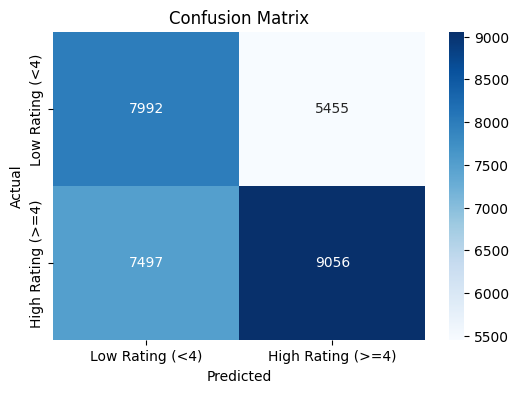

In [32]:
# ============================================================
# STEP 5: EVALUATE MODEL
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===== ACCURACY ====")
print("Accuracy:", accuracy)

print("\n===== CLASSIFICATION REPORT ====")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\n===== CONFUSION MATRIX ====")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [33]:
# ============================================================
# STEP 6: FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n===== FEATURE IMPORTANCE ====")
print(importance_df)


===== FEATURE IMPORTANCE ====
        Feature  Importance
8         Drama    0.372572
17          War    0.147738
10    Film-Noir    0.125694
14      Romance    0.056283
1        Action    0.053258
5        Comedy    0.050938
11       Horror    0.046280
9       Fantasy    0.040839
16     Thriller    0.037940
3     Animation    0.029297
13      Mystery    0.016242
2     Adventure    0.011469
6         Crime    0.006457
12      Musical    0.004937
15       Sci-Fi    0.000056
0       unknown    0.000000
4    Children's    0.000000
7   Documentary    0.000000
18      Western    0.000000


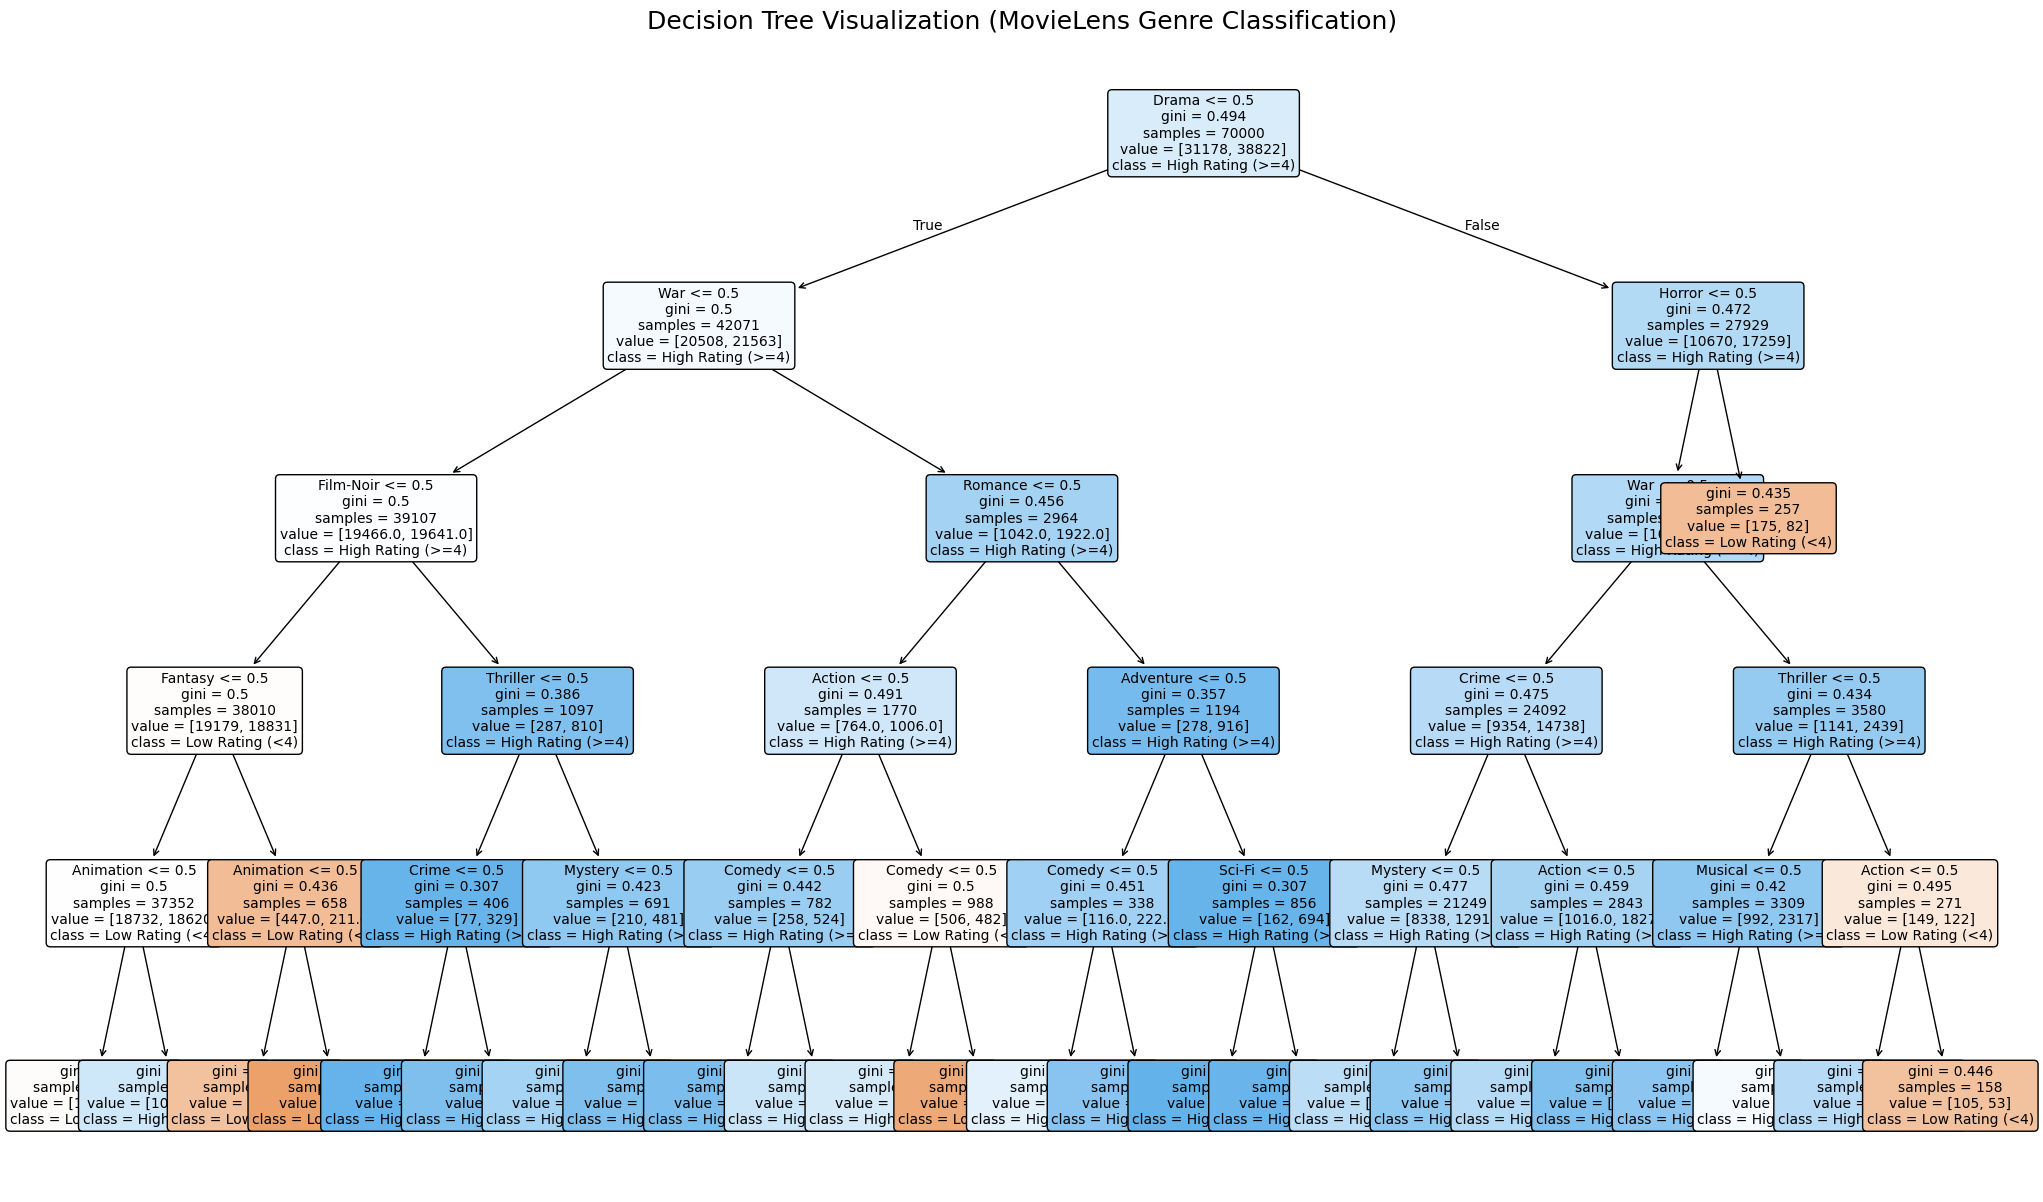

In [34]:
# ============================================================
# STEP 7: VISUALIZE DECISION TREE
# ============================================================

plt.figure(figsize=(25, 15))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization (MovieLens Genre Classification)", fontsize=18)
plt.show()

/tmp/ipykernel_3208/3597090168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


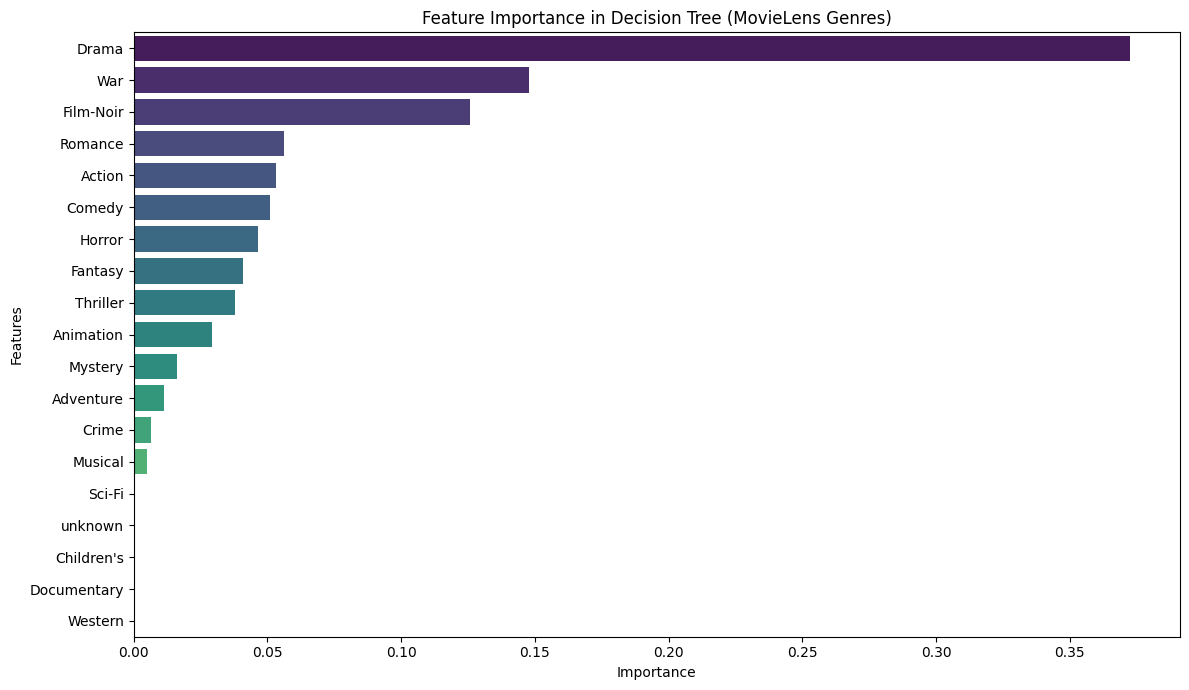


===== PROJECT COMPLETED SUCCESSFULLY ====


In [35]:
# ============================================================
# STEP 8: FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree (MovieLens Genres)")

plt.tight_layout()
plt.show()

print("\n===== PROJECT COMPLETED SUCCESSFULLY ====")